This notebook will map my nuclei collected through the Parse pipeline to clusters produced by the Allen Brain Institute.

Link to MapMyCells tool used: https://knowledge.brain-map.org/mapmycells/process/
- Used the "Hierarchical Mapping" option against 10X Whole Mouse Brain (CCN20230722)

--------

First, let's import raw data, filter out cells based on transcript and gene counts, then make a lean version of the count matrix and save it.

In [1]:
import os
import numpy as np
import scanpy as sc
import pandas as pd
import glasbey as gb
import anndata as ad

data_path = '/Volumes/jack/seq/analysis/combined/0_all-sample/DGE_filtered/'

# import fully clustered dataset
adata = sc.read_h5ad(os.path.join(data_path, 'adata_postClustering.h5ad'))

# trim to bare-bones metadata and save as 'adata_lean' for use w/ MapMyCells
adata_lean = ad.AnnData(adata.layers['denoised'])

adata_lean.var_names = adata.var_names
adata_lean.obs_names = adata.obs_names

adata_lean.write(os.path.join(data_path, 'adata_lean.h5ad'), compression='gzip')

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/Volumes/jack/seq/analysis/combined/0_all-sample/DGE_filtered/adata_postClustering.h5ad', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

Ran MapMyCells

Ok, we have each cell mapped to a cluster in the Allen database, with specific mapping bootstrap probabilities for each cluster. I want to include this as a column in the adata.obs table.

In [ ]:
# read in metadata from two sources: (1) MapMyCells (2) from adata object produced by preprocessing
meta = pd.read_csv(os.path.join(data_path, 'adata_lean_10xWholeMouseBrain(CCN20230722)_HierarchicalMapping_UTC_1705099008682/adata_lean_10xWholeMouseBrain(CCN20230722)_HierarchicalMapping_UTC_1705099008682.csv'),
                   header=4)
meta.set_index(keys='cell_id', drop=True, inplace=True)
meta.index.name = None

# merge MapMyCells metadata into existing adata object
adata.obs = adata.obs.join(meta, how='inner', validate='1:1')
adata.write(os.path.join(data_path, 'adata_postClustering.h5ad'))
adata.obs

,sample,species,gene_count,tscp_count,mread_count,bc1_wind,bc2_wind,bc3_wind,bc1_well,bc2_well,...,subclass_label,subclass_name,subclass_bootstrapping_probability,supertype_label,supertype_name,supertype_bootstrapping_probability,cluster_label,cluster_name,cluster_alias,cluster_bootstrapping_probability
07_01_01__s1,1h1,mm39,3397,12899,20351,7,1,1,A7,A1,...,CS20230722_SUBC_031,031 CT SUB Glut,1.0,CS20230722_SUPT_0120,0120 CT SUB Glut_1,1.00,CS20230722_CLUS_0458,0458 CT SUB Glut_1,53,1.00
07_01_03__s1,1h1,mm39,7312,69490,111017,7,1,3,A7,A1,...,CS20230722_SUBC_023,023 SUB-ProS Glut,1.0,CS20230722_SUPT_0098,0098 SUB-ProS Glut_3,1.00,CS20230722_CLUS_0394,0394 SUB-ProS Glut_3,334,1.00
07_01_04__s1,1h1,mm39,2104,5276,8226,7,1,4,A7,A1,...,CS20230722_SUBC_327,327 Oligo NN,1.0,CS20230722_SUPT_1184,1184 MOL NN_4,0.74,CS20230722_CLUS_5288,5288 MOL NN_4,5237,0.74
07_01_22__s1,1h1,mm39,1851,4287,6748,7,1,22,A7,A1,...,CS20230722_SUBC_038,038 DG-PIR Ex IMN,1.0,CS20230722_SUPT_0141,0141 DG-PIR Ex IMN_2,1.00,CS20230722_CLUS_0514,0514 DG-PIR Ex IMN_2,1406,1.00
07_01_29__s1,1h1,mm39,4879,26001,40860,7,1,29,A7,A1,...,CS20230722_SUBC_025,025 CA2-FC-IG Glut,1.0,CS20230722_SUPT_0100,0100 CA2-FC-IG Glut_1,1.00,CS20230722_CLUS_0399,0399 CA2-FC-IG Glut_1,433,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
06_96_46__s2,SE3,mm39,2280,5741,24079,6,96,46,A6,H12,...,CS20230722_SUBC_016,016 CA1-ProS Glut,1.0,CS20230722_SUPT_0072,0072 CA1-ProS Glut_4,0.93,CS20230722_CLUS_0286,0286 CA1-ProS Glut_4,354,0.93
06_96_47__s2,SE3,mm39,2286,5747,23255,6,96,47,A6,H12,...,CS20230722_SUBC_016,016 CA1-ProS Glut,1.0,CS20230722_SUPT_0069,0069 CA1-ProS Glut_1,0.99,CS20230722_CLUS_0262,0262 CA1-ProS Glut_1,328,0.99
06_96_68__s2,SE3,mm39,3106,11177,47730,6,96,68,A6,H12,...,CS20230722_SUBC_016,016 CA1-ProS Glut,1.0,CS20230722_SUPT_0072,0072 CA1-ProS Glut_4,1.00,CS20230722_CLUS_0288,0288 CA1-ProS Glut_4,362,1.00
06_96_78__s2,SE3,mm39,1157,2404,10205,6,96,78,A6,H12,...,CS20230722_SUBC_327,327 Oligo NN,1.0,CS20230722_SUPT_1182,1182 NFOL NN_2,1.00,CS20230722_CLUS_5281,5281 NFOL NN_2,5222,1.00


In [ ]:
adata.X.shape

(14032, 5224)

In [ ]:
adata.obs.keys()

Index(['sample', 'species', 'gene_count', 'tscp_count', 'mread_count',
       'bc1_wind', 'bc2_wind', 'bc3_wind', 'bc1_well', 'bc2_well', 'bc3_well',
       'sublibrary', 'n_genes_by_counts', 'total_counts', 'total_counts_mt',
       'pct_counts_mt', 'n_counts', 'n_genes', 'size_factors', 'louvain',
       'class_label', 'class_name', 'class_bootstrapping_probability',
       'subclass_label', 'subclass_name', 'subclass_bootstrapping_probability',
       'supertype_label', 'supertype_name',
       'supertype_bootstrapping_probability', 'cluster_label', 'cluster_name',
       'cluster_alias', 'cluster_bootstrapping_probability'],
      dtype='object')

/Users/jack/miniconda3/envs/sc/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/Users/jack/miniconda3/envs/sc/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


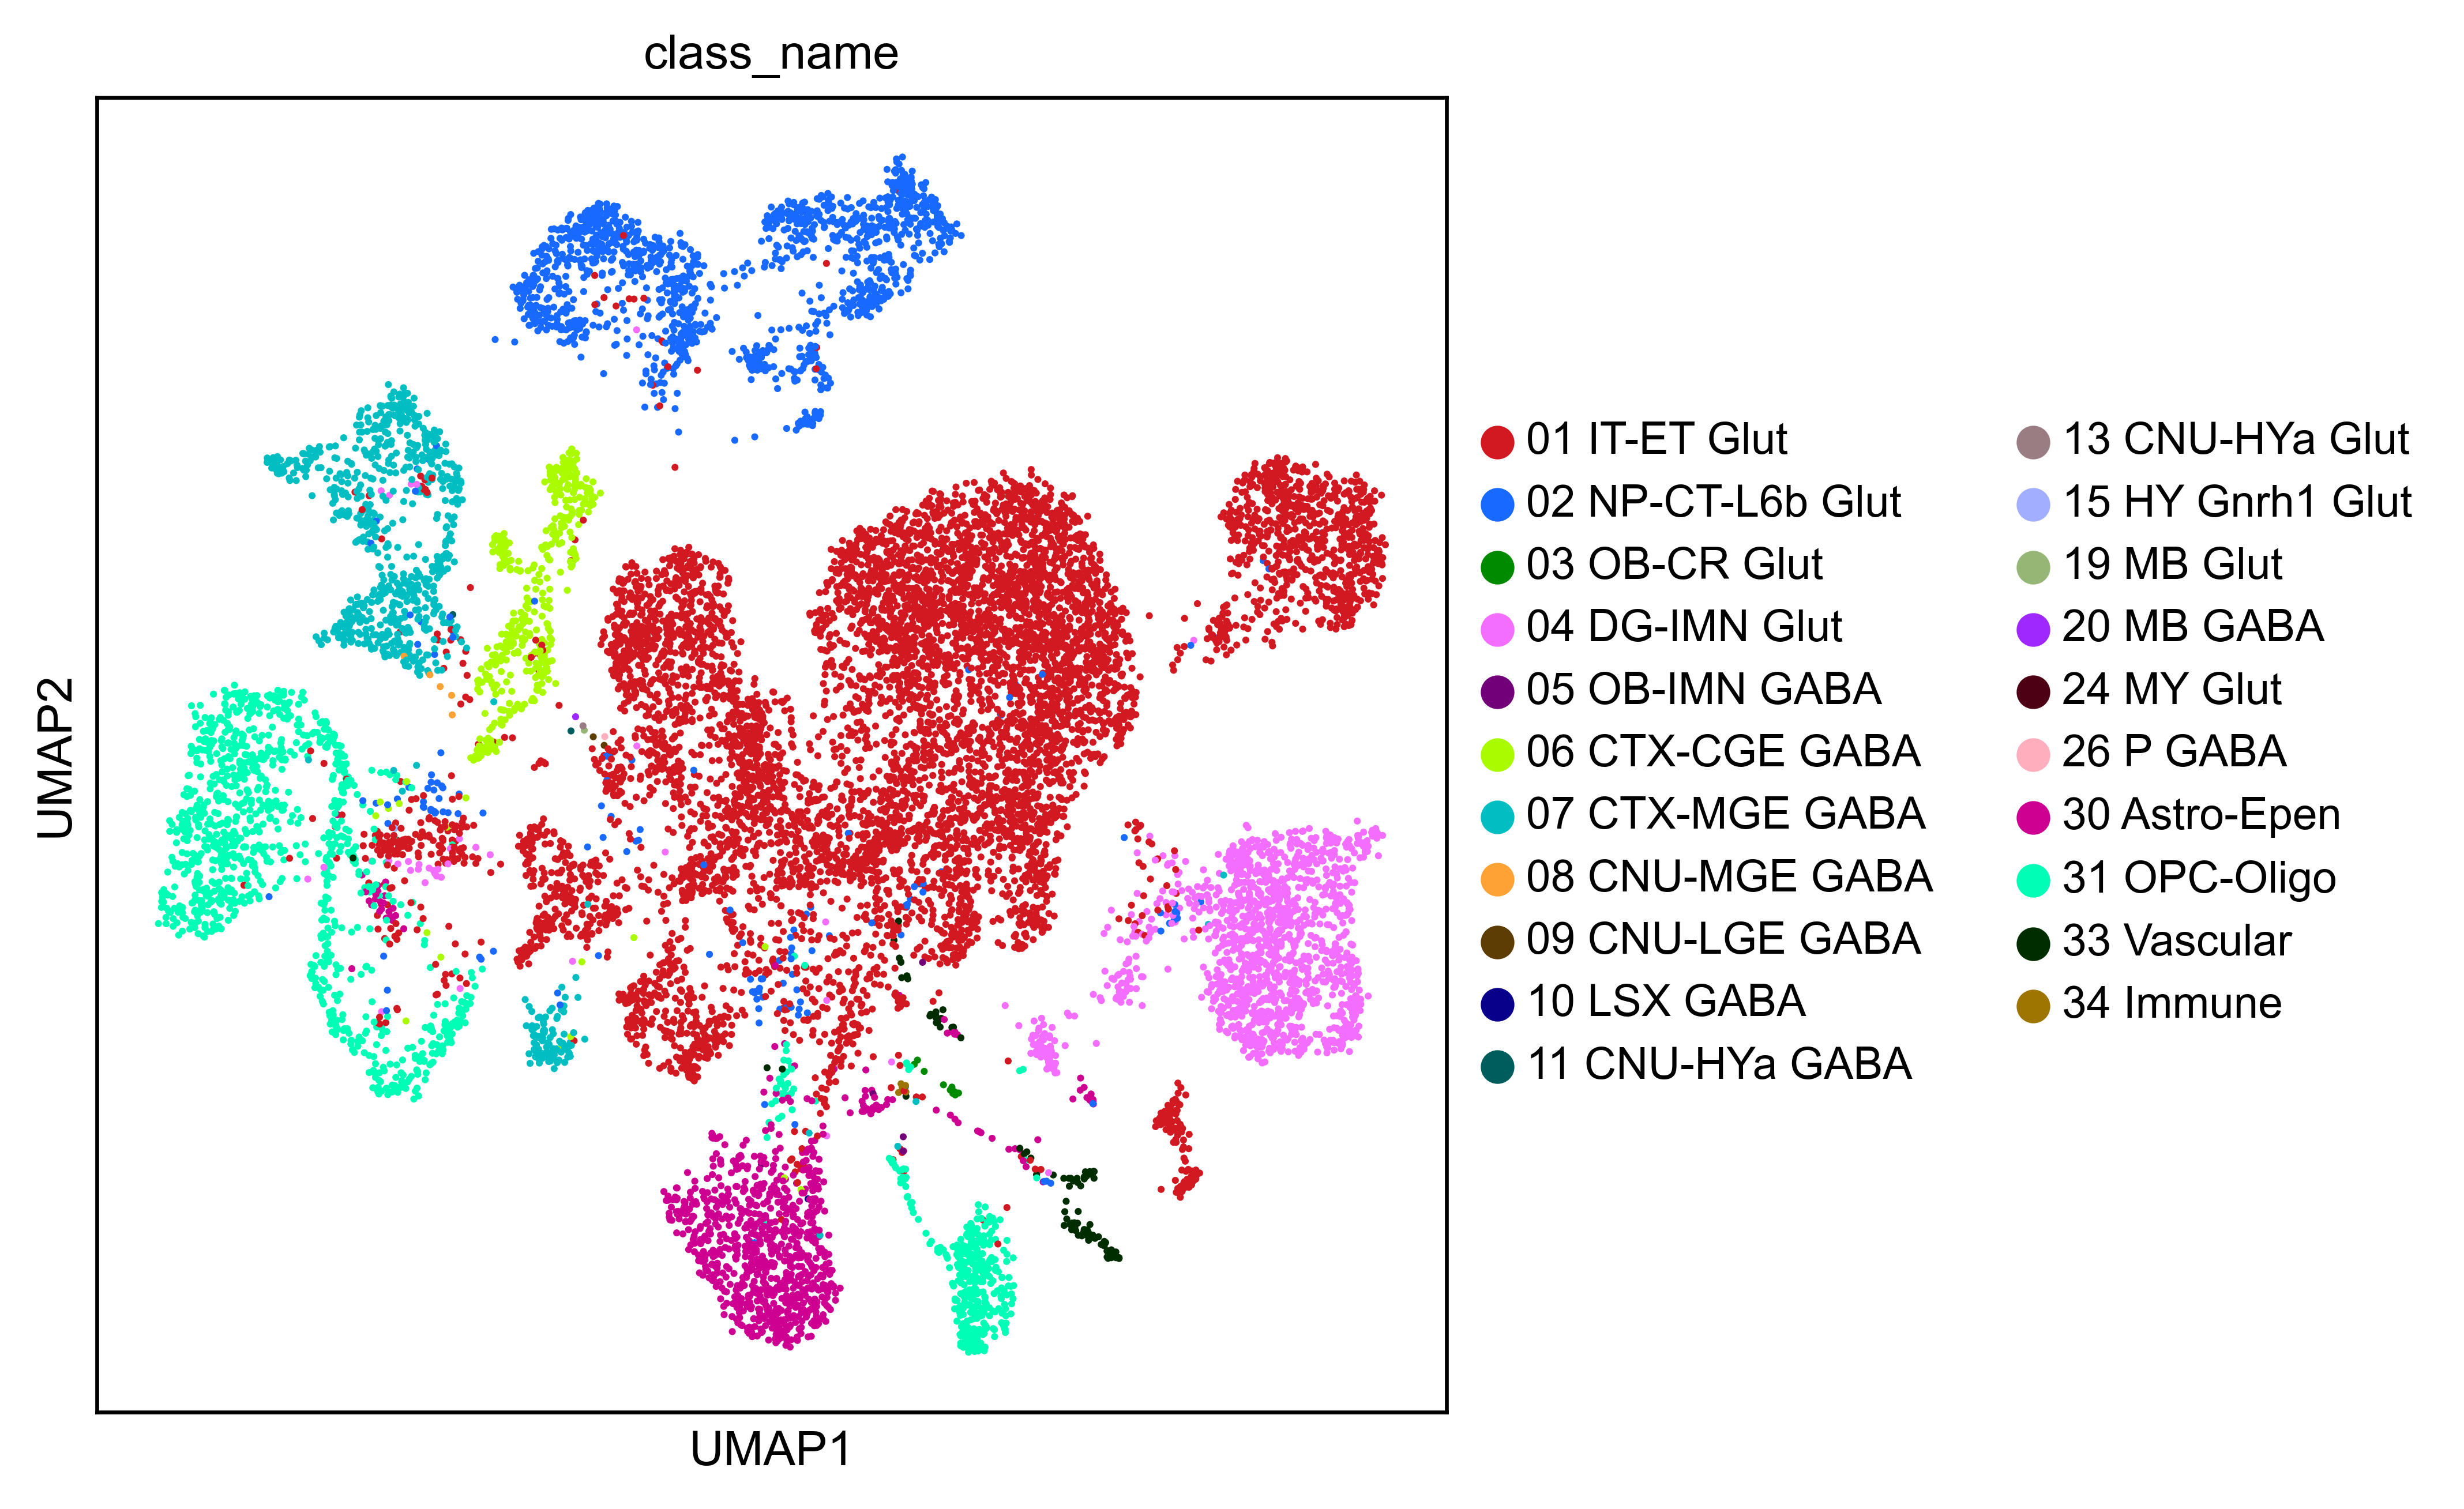

/Users/jack/miniconda3/envs/sc/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/Users/jack/miniconda3/envs/sc/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


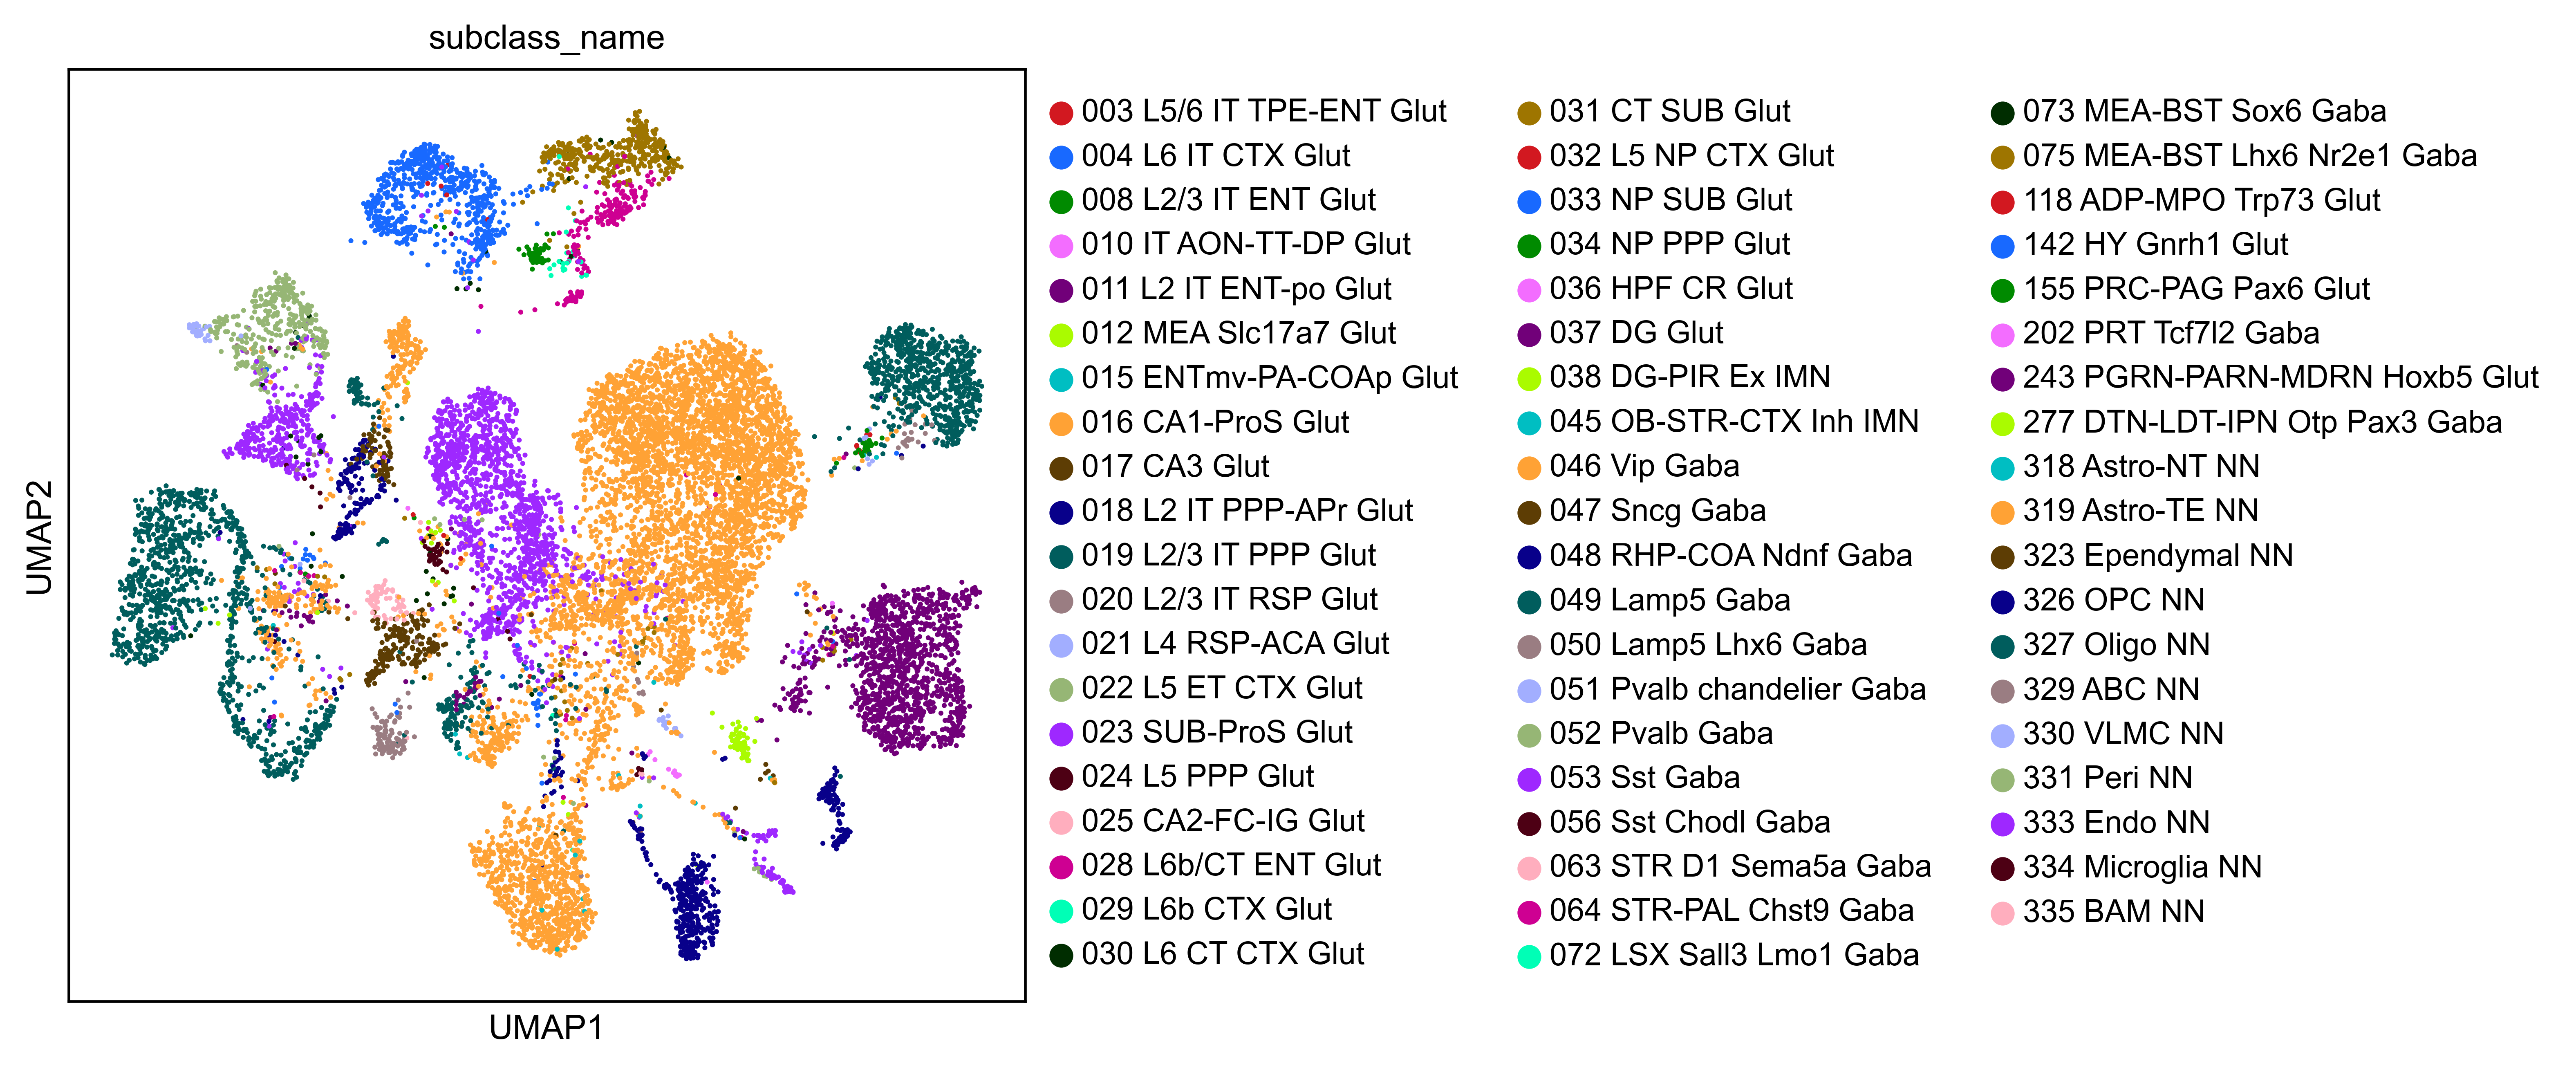

In [ ]:
# create color map large enough for all Allen supertypes/clusters in my data
from matplotlib.colors import ListedColormap

sc.settings.set_figure_params(dpi=300, fontsize=10, dpi_save=300, figsize=(5,5), format='png')

pal = gb.create_palette(palette_size=len(np.unique(adata.obs['class_name'])))
custom_cmap = ListedColormap(pal)

# plot mappings onto Allen classes and subclasses
sc.pl.umap(adata, color=['class_name'], palette=pal)
sc.pl.umap(adata, color=['subclass_name'], palette=pal)

Todos:
- Re-cluster subclass 016 CA1-ProS to identify CA1 sub-types
- Percent sublibrary in each cluster
- Annotation genes in HVGs (and some non-HVGs like Gapdh, Tubulin, Actin, etc)